In [0]:
%pip install tensorflow mlflow scikit-learn matplotlib seaborn pandas numpy
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Verificar todas las estaciones con datos
df_estaciones = spark.table("workspace.default.estacion").toPandas()
df_mediciones = spark.table("workspace.default.medicion").toPandas()

# Contar mediciones por estación
mediciones_por_estacion = df_mediciones.groupby('IdEstacion').size().reset_index(name='NumMediciones')

# Combinar con info de estaciones
estaciones_con_datos = df_estaciones.merge(mediciones_por_estacion, on='IdEstacion', how='left')
estaciones_con_datos['NumMediciones'] = estaciones_con_datos['NumMediciones'].fillna(0).astype(int)

# Filtrar solo las que tienen datos
estaciones_activas = estaciones_con_datos[estaciones_con_datos['NumMediciones'] > 0].sort_values('NumMediciones', ascending=False)

print("="*80)
print("📡 ESTACIONES CON DATOS DISPONIBLES")
print("="*80)
print(f"\n{'ID':<10} {'Nombre':<40} {'Prov':<5} {'Mediciones':<12}")
print("-"*80)

for _, row in estaciones_activas.iterrows():
    id_est = row['IdEstacion']
    nombre = str(row['Nombre'])[:38]
    prov = int(row['IdProvincia'])
    mediciones = int(row['NumMediciones'])
    print(f"{id_est:<10} {nombre:<40} {prov:<5} {mediciones:>11,}")

print("-"*80)
print(f"\n✅ Total estaciones con datos: {len(estaciones_activas)}")
print(f"📦 Total mediciones: {estaciones_activas['NumMediciones'].sum():,}")

# Guardar lista para usar después
estaciones_para_entrenar = estaciones_activas['IdEstacion'].tolist()
print(f"\n📋 IDs para entrenar: {estaciones_para_entrenar}")

📡 ESTACIONES CON DATOS DISPONIBLES

ID         Nombre                                   Prov  Mediciones  
--------------------------------------------------------------------------------
472C2CB6   MARMOT                                   3          43,677
107054     CALLANCAS                                1          43,504
472D60B4   USQUIL                                   1          43,084
472EB1D2   CAPACHIQUE                               1          42,754
107131     LA FORTUNA                               1          42,334
4727319A   QUIRUVILCA                               13         41,438
472D552E   LUCMA                                    3          41,345
472EA2A4   CASCAS                                   3          40,248
108045     CACHICADAN                               13          3,384
107009     HUAMACHUCO                               12          3,368
108068     TRUJILLO                                 4           3,164
108001     SALPO                          

In [0]:
# Cargar las tablas desde Unity Catalog
print("Cargando datos...")

# Tabla de estaciones
df_estaciones = spark.table("workspace.default.estacion").toPandas()

# 🎯 FILTRAR ESTACIONES POR PROVINCIA SELECCIONADA
estaciones_provincia = df_estaciones[df_estaciones['IdProvincia'] == PROVINCIA_SELECCIONADA]['IdEstacion'].tolist()

print(f"\n📍 Estaciones en Provincia {PROVINCIA_SELECCIONADA}:")
for _, est in df_estaciones[df_estaciones['IdProvincia'] == PROVINCIA_SELECCIONADA].iterrows():
    print(f"  - {est['Nombre']}")

if not estaciones_provincia:
    raise ValueError(f"No se encontraron estaciones para la provincia {PROVINCIA_SELECCIONADA}")

# Tabla de mediciones meteorológicas - FILTRADA POR PROVINCIA
df_mediciones_all = spark.table("workspace.default.medicion").toPandas()
df_mediciones = df_mediciones_all[df_mediciones_all['IdEstacion'].isin(estaciones_provincia)].copy()

# Tabla de condiciones ideales para cultivos
df_condiciones = spark.table("workspace.default.condicionesideales").toPandas()

print(f"\n✓ Mediciones totales: {len(df_mediciones_all):,} registros")
print(f"✓ Mediciones de Provincia {PROVINCIA_SELECCIONADA}: {len(df_mediciones):,} registros ({len(df_mediciones)/len(df_mediciones_all)*100:.1f}%)")
print(f"✓ Estaciones en esta provincia: {len(estaciones_provincia)}")
print(f"✓ Condiciones ideales: {len(df_condiciones):,} cultivos")

# Vista rápida de los datos
print("\n=== Resumen de Mediciones (Provincia Seleccionada) ===")
print(df_mediciones.info())
print("\n=== Primeras filas ===")
display(df_mediciones.head())

Cargando datos...

📍 Estaciones en Provincia 4:
  - TRUJILLO

✓ Mediciones totales: 359,678 registros
✓ Mediciones de Provincia 4: 3,164 registros (0.9%)
✓ Estaciones en esta provincia: 1
✓ Condiciones ideales: 104 cultivos

=== Resumen de Mediciones (Provincia Seleccionada) ===
<class 'pandas.core.frame.DataFrame'>
Index: 3164 entries, 154766 to 336297
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   IdMedicion       3164 non-null   int32 
 1   Fecha            3164 non-null   object
 2   TemperaturaMax   3164 non-null   object
 3   Precipitacion    3164 non-null   object
 4   Humedad          3164 non-null   object
 5   VientoVelocidad  0 non-null      object
 6   VientoDireccion  0 non-null      object
 7   IdEstacion       3164 non-null   object
 8   TemperaturaMin   3164 non-null   object
dtypes: int32(1), object(8)
memory usage: 234.8+ KB
None

=== Primeras filas ===


IdMedicion,Fecha,TemperaturaMax,Precipitacion,Humedad,VientoVelocidad,VientoDireccion,IdEstacion,TemperaturaMin
360142,2017-05-26,25.40,0.00,0.00,null,null,108068,0.00
360143,2017-05-27,25.60,0.00,81.50,null,null,108068,17.90
360144,2017-05-28,25.60,0.00,84.90,null,null,108068,17.80
360145,2017-05-29,25.00,0.00,85.70,null,null,108068,19.30
360146,2017-05-30,24.40,0.00,80.80,null,null,108068,19.40


In [0]:
# ============================================================
# SELECCIÓN DE PROVINCIA - Configuración de zona específica
# ============================================================

# Provincias disponibles:
# 4  = Trujillo (23.4°C) - Costa
# 10 = Talla/Guadalupe (28°C) - Costa norte
# 5  = Casagrande (18.4°C) - Valle
# 12 = Huamachuco (18.7°C) - Sierra baja
# 3  = Cascas/Lucma/Marmot (16.4°C) - Zona intermedia
# 1  = Callancas/Salpo/Usquil (13.9°C) - Sierra
# 13 = Mollepata/Cachicadan/Quiruvilca (8.9°C) - Sierra alta

# 🔧 CONFIGURA AQUÍ LA PROVINCIA A PREDECIR:
PROVINCIA_SELECCIONADA = 4  # Trujillo

print("="*60)
print("🌍 CONFIGURACIÓN DE ZONA DE PREDICCIÓN")
print("="*60)
print(f"\nProvincia seleccionada: {PROVINCIA_SELECCIONADA}")

# Información de provincias
info_provincias = {
    4: {"nombre": "Trujillo", "zona": "Costa", "temp": "23.4°C"},
    10: {"nombre": "Talla/Guadalupe", "zona": "Costa Norte", "temp": "28°C"},
    5: {"nombre": "Casagrande", "zona": "Valle", "temp": "18.4°C"},
    12: {"nombre": "Huamachuco", "zona": "Sierra Baja", "temp": "18.7°C"},
    3: {"nombre": "Cascas/Lucma/Marmot", "zona": "Intermedia", "temp": "16.4°C"},
    1: {"nombre": "Callancas/Salpo/Usquil", "zona": "Sierra", "temp": "13.9°C"},
    13: {"nombre": "Mollepata/Cachicadan/Quiruvilca", "zona": "Sierra Alta", "temp": "8.9°C"}
}

if PROVINCIA_SELECCIONADA in info_provincias:
    info = info_provincias[PROVINCIA_SELECCIONADA]
    print(f"Zona: {info['nombre']}")
    print(f"Tipo: {info['zona']}")
    print(f"Temperatura promedio histórica: {info['temp']}")
else:
    print(f"⚠️ Provincia {PROVINCIA_SELECCIONADA} no reconocida")

print("\n💡 El modelo entrenará SOLO con datos de esta provincia")
print("="*60)

🌍 CONFIGURACIÓN DE ZONA DE PREDICCIÓN

Provincia seleccionada: 4
Zona: Trujillo
Tipo: Costa
Temperatura promedio histórica: 23.4°C

💡 El modelo entrenará SOLO con datos de esta provincia


In [0]:
# Convertir Fecha a datetime si no lo es
df_mediciones['Fecha'] = pd.to_datetime(df_mediciones['Fecha'])

# Convertir columnas numéricas de object a float
numeric_cols = ['TemperaturaMax', 'TemperaturaMin', 'Precipitacion', 'Humedad', 'VientoVelocidad', 'VientoDireccion']
for col in numeric_cols:
    if col in df_mediciones.columns:
        df_mediciones[col] = pd.to_numeric(df_mediciones[col], errors='coerce')

# Estadísticas descriptivas
print("=== Estadísticas Descriptivas ===")
print(df_mediciones.describe())

# Verificar valores nulos
print("\n=== Valores Nulos por Columna ===")
nulos = df_mediciones.isnull().sum()
print(nulos[nulos > 0])

# Rango de fechas
print(f"\n=== Rango Temporal ===")
print(f"Fecha mínima: {df_mediciones['Fecha'].min()}")
print(f"Fecha máxima: {df_mediciones['Fecha'].max()}")
print(f"Días de datos: {(df_mediciones['Fecha'].max() - df_mediciones['Fecha'].min()).days}")

# Distribución por estación
print(f"\n=== Mediciones por Estación ===")
print(df_mediciones['IdEstacion'].value_counts())

=== Estadísticas Descriptivas ===
          IdMedicion  ... TemperaturaMin
count    3164.000000  ...    3164.000000
mean   361723.500000  ...      16.485272
min    360142.000000  ...       0.000000
25%    360932.750000  ...      15.000000
50%    361723.500000  ...      16.800000
75%    362514.250000  ...      18.700000
max    363305.000000  ...      24.600000
std       913.512452  ...       4.036613

[8 rows x 8 columns]

=== Valores Nulos por Columna ===
VientoVelocidad    3164
VientoDireccion    3164
dtype: int64

=== Rango Temporal ===
Fecha mínima: 2017-05-26 00:00:00
Fecha máxima: 2026-05-19 00:00:00
Días de datos: 3280

=== Mediciones por Estación ===
IdEstacion
108068    3164
Name: count, dtype: int64


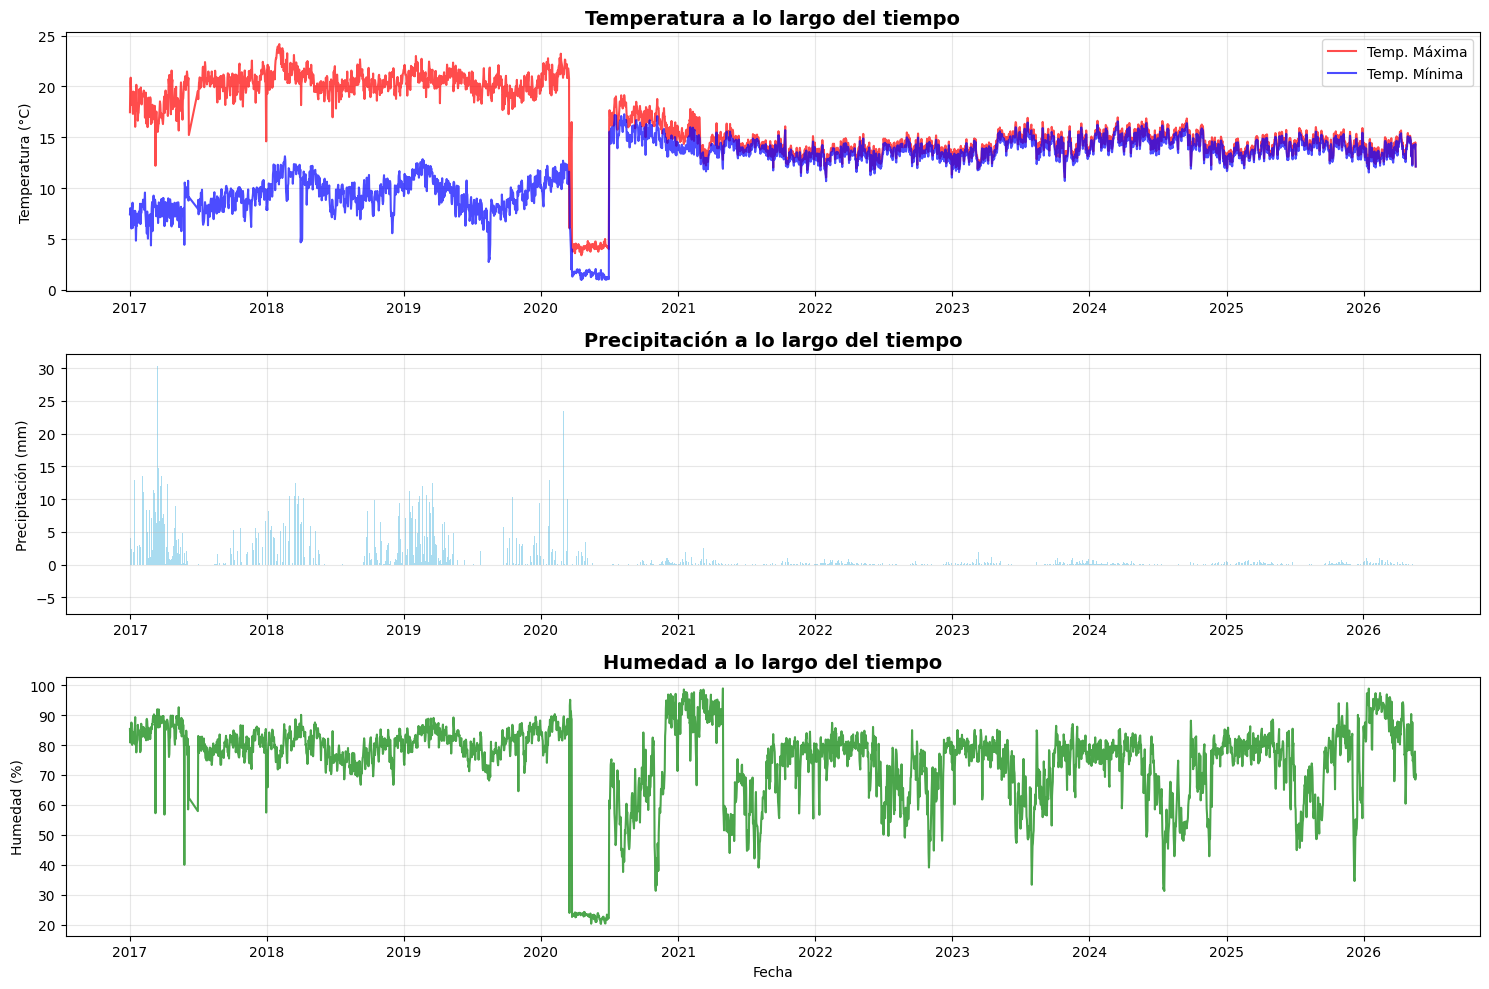

✓ Visualizaciones generadas


In [0]:
# Crear visualizaciones de las series temporales
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Agrupar por fecha (promedio de todas las estaciones)
df_daily = df_mediciones.groupby('Fecha').agg({
    'TemperaturaMax': 'mean',
    'TemperaturaMin': 'mean',
    'Precipitacion': 'mean',
    'Humedad': 'mean'
}).reset_index()

# Temperatura
axes[0].plot(df_daily['Fecha'], df_daily['TemperaturaMax'], label='Temp. Máxima', color='red', alpha=0.7)
axes[0].plot(df_daily['Fecha'], df_daily['TemperaturaMin'], label='Temp. Mínima', color='blue', alpha=0.7)
axes[0].set_title('Temperatura a lo largo del tiempo', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precipitación
axes[1].bar(df_daily['Fecha'], df_daily['Precipitacion'], color='skyblue', alpha=0.7)
axes[1].set_title('Precipitación a lo largo del tiempo', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Precipitación (mm)')
axes[1].grid(True, alpha=0.3)

# Humedad
axes[2].plot(df_daily['Fecha'], df_daily['Humedad'], color='green', alpha=0.7)
axes[2].set_title('Humedad a lo largo del tiempo', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Humedad (%)')
axes[2].set_xlabel('Fecha')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizaciones generadas")

In [0]:
# Seleccionar las variables a predecir
# Para Trujillo: TemperaturaMax, TemperaturaMin, Precipitacion, Humedad
# (VientoVelocidad tiene valores nulos para esta estación)

# Ordenar por fecha y preparar dataset diario
df_daily = df_mediciones.groupby('Fecha').agg({
    'TemperaturaMax': 'mean',
    'TemperaturaMin': 'mean',
    'Precipitacion': 'mean',
    'Humedad': 'mean'
}).reset_index().sort_values('Fecha')

# Rellenar valores nulos con interpolación
df_daily = df_daily.set_index('Fecha')
df_daily = df_daily.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')

print(f"Dataset preparado: {len(df_daily)} días")
print(f"Columnas: {list(df_daily.columns)}")
print(f"\nPrimeras filas:")
display(df_daily.head())

# Normalizar los datos (importante para LSTM)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_daily)

print(f"\n✓ Datos normalizados: shape {scaled_data.shape}")

Dataset preparado: 3160 días
Columnas: ['TemperaturaMax', 'TemperaturaMin', 'Precipitacion', 'Humedad']

Primeras filas:


TemperaturaMax,TemperaturaMin,Precipitacion,Humedad
25.4,0.0,0.0,0.0
25.6,17.9,0.0,81.5
25.6,17.8,0.0,84.9
25.0,19.3,0.0,85.7
24.4,19.4,0.0,80.8



✓ Datos normalizados: shape (3160, 4)


In [0]:
def create_sequences(data, lookback=30, forecast_horizon=7):
    """
    Crea secuencias para entrenamiento de LSTM
    
    Args:
        data: array de datos normalizados
        lookback: número de días históricos para usar como entrada
        forecast_horizon: número de días futuros a predecir
    
    Returns:
        X: secuencias de entrada
        y: valores objetivo
    """
    X, y = [], []
    
    for i in range(lookback, len(data) - forecast_horizon + 1):
        # Entrada: últimos 'lookback' días
        X.append(data[i-lookback:i])
        # Salida: siguiente día (o siguientes forecast_horizon días)
        y.append(data[i:i+forecast_horizon])
    
    return np.array(X), np.array(y)

# Configuración de parámetros
LOOKBACK = 30  # Usar 30 días de historial
FORECAST_HORIZON = 7  # Predecir 7 días adelante

# Crear secuencias
X, y = create_sequences(scaled_data, lookback=LOOKBACK, forecast_horizon=FORECAST_HORIZON)

print(f"Secuencias creadas:")
print(f"  X shape: {X.shape} (samples, lookback, features)")
print(f"  y shape: {y.shape} (samples, forecast_horizon, features)")

# Dividir en train/validation/test (70/15/15)
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(f"\nDivisión de datos:")
print(f"  Train: {X_train.shape[0]} secuencias ({train_size/len(X)*100:.1f}%)")
print(f"  Validation: {X_val.shape[0]} secuencias ({val_size/len(X)*100:.1f}%)")
print(f"  Test: {X_test.shape[0]} secuencias ({len(X_test)/len(X)*100:.1f}%)")

Secuencias creadas:
  X shape: (3124, 30, 4) (samples, lookback, features)
  y shape: (3124, 7, 4) (samples, forecast_horizon, features)

División de datos:
  Train: 2186 secuencias (70.0%)
  Validation: 468 secuencias (15.0%)
  Test: 470 secuencias (15.0%)


In [0]:
# Construir modelo LSTM
def build_lstm_model(lookback, n_features, forecast_horizon, lstm_units=[64, 32]):
    """
    Construye un modelo LSTM para predicción de series temporales multivariadas
    
    Args:
        lookback: ventana de tiempo de entrada
        n_features: número de variables a predecir
        forecast_horizon: número de días a predecir
        lstm_units: lista con el número de unidades en cada capa LSTM
    """
    model = Sequential([
        # Primera capa LSTM con return_sequences=True
        LSTM(lstm_units[0], activation='relu', return_sequences=True, 
             input_shape=(lookback, n_features)),
        Dropout(0.2),
        
        # Segunda capa LSTM
        LSTM(lstm_units[1], activation='relu', return_sequences=False),
        Dropout(0.2),
        
        # Capa densa para generar predicciones
        Dense(forecast_horizon * n_features),
        
        # Reshape para obtener (forecast_horizon, n_features)
        tf.keras.layers.Reshape((forecast_horizon, n_features))
    ])
    
    # Compilar modelo
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

# Parámetros del modelo
n_features = X_train.shape[2]  # Número de variables (TemperaturaMax, Min, Precipitacion, etc.)

# Construir el modelo
model = build_lstm_model(
    lookback=LOOKBACK,
    n_features=n_features,
    forecast_horizon=FORECAST_HORIZON,
    lstm_units=[64, 32]
)

# Resumen del modelo
print("=== Arquitectura del Modelo LSTM ===")
model.summary()

print(f"\n✓ Modelo construido exitosamente")
print(f"Parámetros totales: {model.count_params():,}")

=== Arquitectura del Modelo LSTM ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │           924 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 4)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,004 (121.11 KB)

 Trainable params: 31,004 (121.11 KB)

 Non-trainable params: 0 (0.00 B)


✓ Modelo construido exitosamente
Parámetros totales: 31,004


In [0]:
# Configurar MLflow
mlflow.set_experiment("/Users/lmauriccib1@upao.edu.pe/LSTM-Prediccion-Clima")

# Nombre del run con provincia
info = info_provincias.get(PROVINCIA_SELECCIONADA, {"nombre": f"Prov{PROVINCIA_SELECCIONADA}"})
run_name = f"LSTM_{info['nombre'].replace('/', '_')}_Prov{PROVINCIA_SELECCIONADA}"

# Iniciar experimento MLflow
with mlflow.start_run(run_name=run_name):
    
    # Log de parámetros
    mlflow.log_param("provincia", PROVINCIA_SELECCIONADA)
    mlflow.log_param("zona", info.get('nombre', 'N/A'))
    mlflow.log_param("lookback", LOOKBACK)
    mlflow.log_param("forecast_horizon", FORECAST_HORIZON)
    mlflow.log_param("lstm_units", "64,32")
    mlflow.log_param("dropout", 0.2)
    mlflow.log_param("learning_rate", 0.001)
    mlflow.log_param("train_size", train_size)
    mlflow.log_param("val_size", val_size)
    
    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
    
    # Entrenar modelo
    print("=== Entrenando Modelo LSTM ===")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Evaluar en test set
    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\n=== Resultados en Test Set ===")
    print(f"Test Loss (MSE): {test_loss:.6f}")
    print(f"Test MAE: {test_mae:.6f}")
    
    # Log de métricas
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("final_train_loss", history.history['loss'][-1])
    mlflow.log_metric("final_val_loss", history.history['val_loss'][-1])
    
    # Log del modelo
    mlflow.tensorflow.log_model(model, "lstm_model")
    
    print("\n✓ Entrenamiento completado y modelo registrado en MLflow")

If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


=== Entrenando Modelo LSTM ===
Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.2660 - mae: 0.4100 - val_loss: 0.0192 - val_mae: 0.1107
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0588 - mae: 0.1880 - val_loss: 0.0088 - val_mae: 0.0651
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0422 - mae: 0.1583 - val_loss: 0.0105 - val_mae: 0.0772
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0349 - mae: 0.1437 - val_loss: 0.0087 - val_mae: 0.0667
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0300 - mae: 0.1321 - val_loss: 0.0076 - val_mae: 0.0620
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0266 - mae: 0.1242 - val_loss: 0.0095 - val_mae: 0.0768
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0250 - mae: 0.1194 - val_loss: 0.0083 - val_mae: 0.0705
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0226 - mae: 0.1123 - val_loss: 0.0061 - val_mae: 0.0539
Epoch 9/100
69/69 ━━━━━━━

2026/07/10 21:59:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-62e05482-95ba.cloud.databricks.com/ml/experiments/4393848848577059/models/m-5f1b7c1161b949f4a0edbedfb3444712?o=7474645150639733
2026/07/10 21:59:21 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/07/10 21:59:29 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.14.0/ml/model/signatures.html for instructions on setting signature on models.



✓ Entrenamiento completado y modelo registrado en MLflow


In [0]:
import pickle
import os

# Crear directorio para modelos si no existe
models_dir = "/Workspace/Users/lmauriccib1@upao.edu.pe/clima-api/models"
os.makedirs(models_dir, exist_ok=True)

print("="*70)
print("💾 GUARDANDO MODELO Y SCALER ENTRENADOS")
print("="*70)

# Nombre de archivos basado en provincia
provincia_id = PROVINCIA_SELECCIONADA
model_path = f"{models_dir}/modelo_provincia_{provincia_id}.h5"
scaler_path = f"{models_dir}/scaler_provincia_{provincia_id}.pkl"
metadata_path = f"{models_dir}/metadata_provincia_{provincia_id}.pkl"

# 1. Guardar modelo LSTM
print(f"\n[1/3] Guardando modelo LSTM...")
model.save(model_path)
print(f"   ✓ Modelo guardado en: {model_path}")

# 2. Guardar scaler
print(f"\n[2/3] Guardando scaler...")
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"   ✓ Scaler guardado en: {scaler_path}")

# 3. Guardar metadata
print(f"\n[3/3] Guardando metadata...")
metadata = {
    'provincia_id': provincia_id,
    'zona': info_provincias.get(provincia_id, {}).get('nombre', 'N/A'),
    'last_date': df_daily.index[-1],
    'num_registros': len(df_daily),
    'lookback': LOOKBACK,
    'forecast_horizon': FORECAST_HORIZON,
    'test_loss': test_loss,
    'test_mae': test_mae,
    'trained_at': datetime.now(),
    'feature_names': feature_names
}

with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)
print(f"   ✓ Metadata guardada en: {metadata_path}")

print("\n" + "="*70)
print("✅ MODELO GUARDADO EXITOSAMENTE")
print("="*70)
print(f"\nArchivos generados:")
print(f"  1. {model_path}")
print(f"  2. {scaler_path}")
print(f"  3. {metadata_path}")

print(f"\n💡 Siguiente paso:")
print(f"   1. Cambia PROVINCIA_SELECCIONADA en celda 3")
print(f"   2. Re-ejecuta celdas 2-9 y esta celda")
print(f"   3. Repite para todas las provincias (1, 3, 4, 5, 10, 12, 13)")
print(f"   4. Descarga la carpeta /clima-api/models/ completa")
print(f"   5. Súbela a tu repositorio de GitHub")

💾 GUARDANDO MODELO Y SCALER ENTRENADOS

[1/3] Guardando modelo LSTM...
   ✓ Modelo guardado en: /Workspace/Users/lmauriccib1@upao.edu.pe/clima-api/models/modelo_provincia_4.h5

[2/3] Guardando scaler...
   ✓ Scaler guardado en: /Workspace/Users/lmauriccib1@upao.edu.pe/clima-api/models/scaler_provincia_4.pkl

[3/3] Guardando metadata...
   ✓ Metadata guardada en: /Workspace/Users/lmauriccib1@upao.edu.pe/clima-api/models/metadata_provincia_4.pkl

✅ MODELO GUARDADO EXITOSAMENTE

Archivos generados:
  1. /Workspace/Users/lmauriccib1@upao.edu.pe/clima-api/models/modelo_provincia_4.h5
  2. /Workspace/Users/lmauriccib1@upao.edu.pe/clima-api/models/scaler_provincia_4.pkl
  3. /Workspace/Users/lmauriccib1@upao.edu.pe/clima-api/models/metadata_provincia_4.pkl

💡 Siguiente paso:
   1. Cambia PROVINCIA_SELECCIONADA en celda 3
   2. Re-ejecuta celdas 2-9 y esta celda
   3. Repite para todas las provincias (1, 3, 4, 5, 10, 12, 13)
   4. Descarga la carpeta /clima-api/models/ completa
   5. Súbela a 

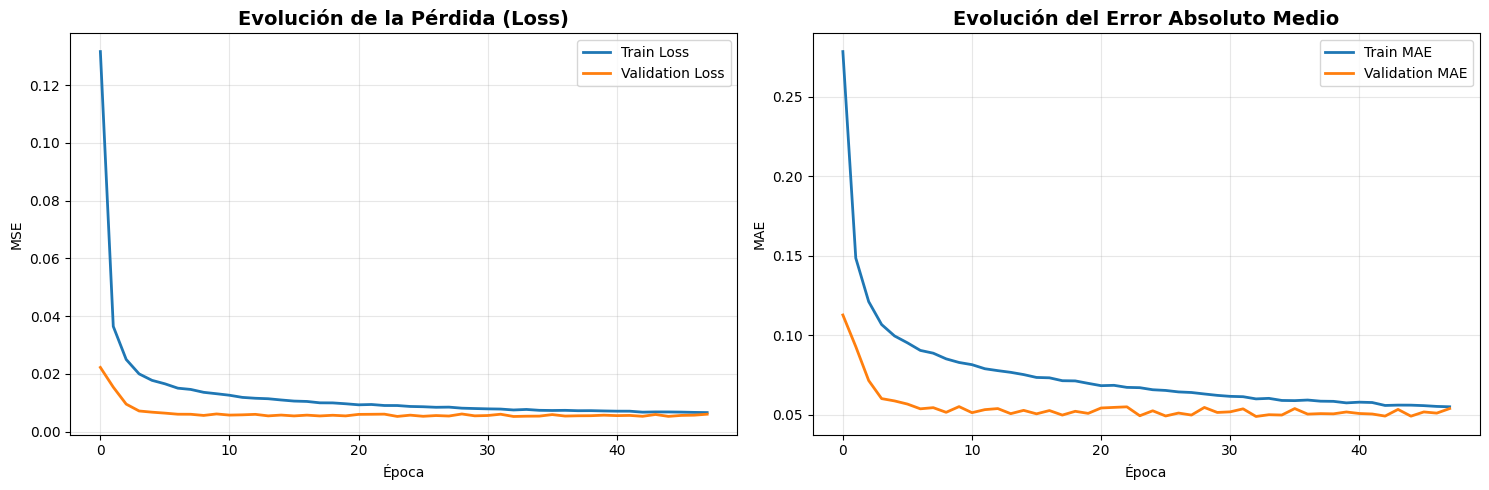

✓ Curvas de entrenamiento generadas


In [0]:
# Visualizar el progreso del entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Evolución de la Pérdida (Loss)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('Evolución del Error Absoluto Medio', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Curvas de entrenamiento generadas")

In [0]:
# Hacer predicciones en el conjunto de test
y_pred_test = model.predict(X_test)

# Desnormalizar predicciones y valores reales
y_test_inv = scaler.inverse_transform(y_test[:, 0, :])  # Primer día de cada secuencia
y_pred_inv = scaler.inverse_transform(y_pred_test[:, 0, :])  # Primer día predicho

# Calcular métricas por variable
feature_names = ['TemperaturaMax', 'TemperaturaMin', 'Precipitacion', 'Humedad']

print("=== Métricas de Predicción por Variable ===")
for i, feature in enumerate(feature_names):
    mse = mean_squared_error(y_test_inv[:, i], y_pred_inv[:, i])
    mae = mean_absolute_error(y_test_inv[:, i], y_pred_inv[:, i])
    r2 = r2_score(y_test_inv[:, i], y_pred_inv[:, i])
    print(f"\n{feature}:")
    print(f"  MSE: {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R²: {r2:.4f}")

print("\n✓ Métricas calculadas")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
=== Métricas de Predicción por Variable ===

TemperaturaMax:
  MSE: 1.4876
  MAE: 0.9785
  R²: 0.8023

TemperaturaMin:
  MSE: 1.4843
  MAE: 0.9190
  R²: 0.7239

Precipitacion:
  MSE: 484.4545
  MAE: 20.9038
  R²: -687.7442

Humedad:
  MSE: 16.2019
  MAE: 3.2508
  R²: -0.3169

✓ Métricas calculadas


In [0]:
# Generar predicciones hacia el futuro
def predict_future(model, last_sequence, n_days, scaler):
    """
    Genera predicciones futuras iterativamente
    
    Args:
        model: modelo LSTM entrenado
        last_sequence: última secuencia de datos conocidos (normalizada)
        n_days: número de días a predecir
        scaler: scaler usado para normalizar los datos
    
    Returns:
        predicciones desnormalizadas
    """
    predictions = []
    current_sequence = last_sequence.copy()
    
    for _ in range(n_days):
        # Predecir siguiente secuencia
        pred = model.predict(current_sequence.reshape(1, LOOKBACK, -1), verbose=0)
        
        # Tomar solo el primer día de la predicción
        next_day = pred[0, 0, :]
        predictions.append(next_day)
        
        # Actualizar secuencia: eliminar el día más antiguo y agregar el nuevo
        current_sequence = np.vstack([current_sequence[1:], next_day])
    
    # Desnormalizar predicciones
    predictions = np.array(predictions)
    predictions_inv = scaler.inverse_transform(predictions)
    
    return predictions_inv

# Obtener la última secuencia de datos conocidos
last_known_sequence = scaled_data[-LOOKBACK:]

# Predecir los próximos 30 días
N_DAYS_FUTURE = 30
future_predictions = predict_future(model, last_known_sequence, N_DAYS_FUTURE, scaler)

# Crear DataFrame con las predicciones
last_date = df_daily.index[-1]
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=N_DAYS_FUTURE, freq='D')

df_future = pd.DataFrame(
    future_predictions,
    index=future_dates,
    columns=feature_names
)

print(f"=== Predicciones para los próximos {N_DAYS_FUTURE} días ===")
print(f"Desde: {future_dates[0].strftime('%Y-%m-%d')}")
print(f"Hasta: {future_dates[-1].strftime('%Y-%m-%d')}")
print(f"\nPrimeras predicciones:")
display(df_future.head(10))

print(f"\n✓ Predicciones futuras generadas")

=== Predicciones para los próximos 30 días ===
Desde: 2026-05-20
Hasta: 2026-06-18

Primeras predicciones:


TemperaturaMax,TemperaturaMin,Precipitacion,Humedad
26.943506,19.53825,-17.549475,82.20474
26.841532,19.46192,-18.982277,82.19149
26.74741,19.391256,-20.199678,82.13997
26.664358,19.328472,-21.191572,82.079124
26.594889,19.275248,-21.931084,82.0293
26.537197,19.231146,-22.477013,81.9886
26.491362,19.19595,-22.858881,81.95909
26.45446,19.167835,-23.131783,81.937195
26.424374,19.145233,-23.32395,81.92182
26.40055,19.12757,-23.4498,81.91169



✓ Predicciones futuras generadas


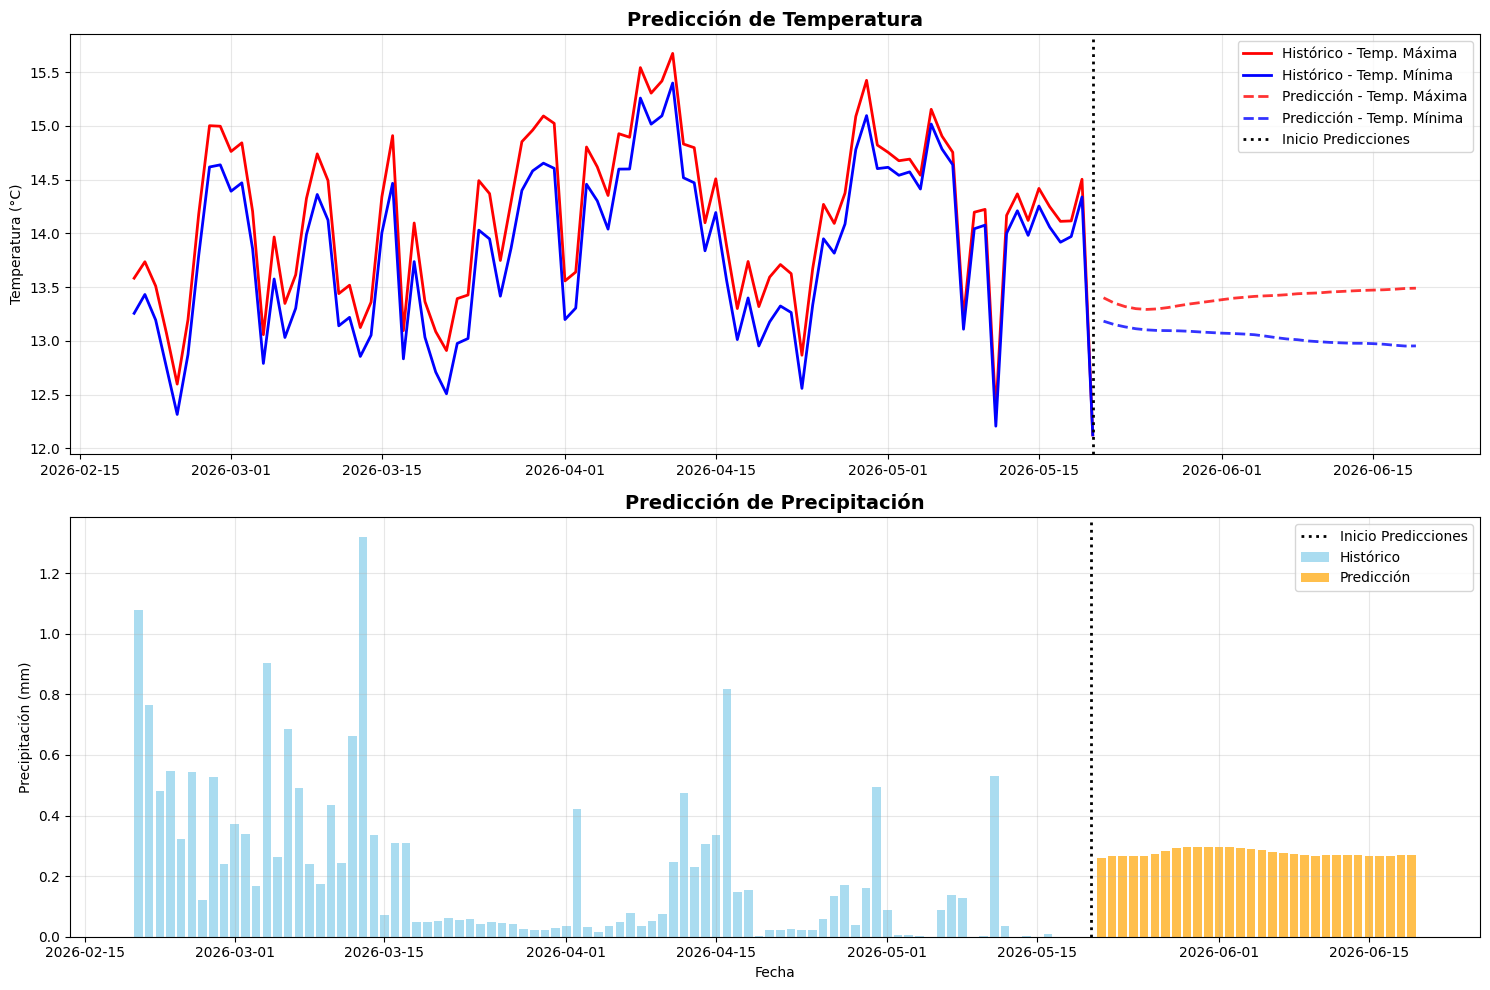

✓ Visualizaciones de predicciones generadas


In [0]:
# Visualizar predicciones futuras vs histórico
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Seleccionar últimos 90 días históricos para contexto
historical_days = 90
df_recent = df_daily.iloc[-historical_days:]

# Temperatura
axes[0].plot(df_recent.index, df_recent['TemperaturaMax'], 
             label='Histórico - Temp. Máxima', color='red', linewidth=2)
axes[0].plot(df_recent.index, df_recent['TemperaturaMin'], 
             label='Histórico - Temp. Mínima', color='blue', linewidth=2)
axes[0].plot(df_future.index, df_future['TemperaturaMax'], 
             label='Predicción - Temp. Máxima', color='red', linestyle='--', linewidth=2, alpha=0.8)
axes[0].plot(df_future.index, df_future['TemperaturaMin'], 
             label='Predicción - Temp. Mínima', color='blue', linestyle='--', linewidth=2, alpha=0.8)
axes[0].axvline(x=last_date, color='black', linestyle=':', linewidth=2, label='Inicio Predicciones')
zona_info = info_provincias.get(PROVINCIA_SELECCIONADA, {})
axes[0].set_title(f'Predicción de Temperatura - {zona_info.get("nombre", f"Prov{PROVINCIA_SELECCIONADA}")}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Precipitación
axes[1].bar(df_recent.index, df_recent['Precipitacion'], 
            label='Histórico', color='skyblue', alpha=0.7, width=0.8)
axes[1].bar(df_future.index, df_future['Precipitacion'], 
            label='Predicción', color='orange', alpha=0.7, width=0.8)
axes[1].axvline(x=last_date, color='black', linestyle=':', linewidth=2, label='Inicio Predicciones')
axes[1].set_title(f'Predicción de Precipitación - {zona_info.get("nombre", f"Prov{PROVINCIA_SELECCIONADA}")}', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Precipitación (mm)')
axes[1].set_xlabel('Fecha')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizaciones de predicciones generadas")

In [0]:
# Calcular promedios de las condiciones predichas para el período futuro
avg_temp_max = df_future['TemperaturaMax'].mean()
avg_temp_min = df_future['TemperaturaMin'].mean()
avg_precipitacion = df_future['Precipitacion'].sum()  # Acumulada
avg_humedad = df_future['Humedad'].mean()

print("=== Condiciones Predichas Promedio (Próximos 30 días) ===")
print(f"Temperatura Máxima Promedio: {avg_temp_max:.2f}°C")
print(f"Temperatura Mínima Promedio: {avg_temp_min:.2f}°C")
print(f"Precipitación Acumulada: {avg_precipitacion:.2f} mm")
print(f"Humedad Promedio: {avg_humedad:.2f}%")

# Función de puntuación para cada cultivo
def score_crop(row, temp_max, temp_min, precip_total):
    """
    Calcula un score de idoneidad para un cultivo basado en las condiciones predichas.
    Score = 100 si está en rango óptimo, disminuye si está fuera pero tolerable,
    0 si está fuera del rango absoluto.
    """
    score = 0
    penalties = []
    
    # Evaluar temperatura máxima
    if pd.notna(row['temperatura_optima_min']) and pd.notna(row['temperatura_optima_max']):
        if row['temperatura_optima_min'] <= temp_max <= row['temperatura_optima_max']:
            score += 35  # Óptimo
        elif pd.notna(row['temperatura_absoluta_min']) and pd.notna(row['temperatura_absoluta_max']):
            if row['temperatura_absoluta_min'] <= temp_max <= row['temperatura_absoluta_max']:
                score += 20  # Tolerable
                penalties.append(f"Temp. máxima fuera de rango óptimo ({row['temperatura_optima_min']}-{row['temperatura_optima_max']}°C)")
            else:
                penalties.append(f"Temp. máxima fuera de rango absoluto ({row['temperatura_absoluta_min']}-{row['temperatura_absoluta_max']}°C)")
                return 0, penalties  # No viable
    
    # Evaluar temperatura mínima
    if pd.notna(row['temperatura_optima_min']) and pd.notna(row['temperatura_optima_max']):
        if row['temperatura_optima_min'] <= temp_min <= row['temperatura_optima_max']:
            score += 35  # Óptimo
        elif pd.notna(row['temperatura_absoluta_min']) and pd.notna(row['temperatura_absoluta_max']):
            if row['temperatura_absoluta_min'] <= temp_min <= row['temperatura_absoluta_max']:
                score += 20  # Tolerable
                penalties.append(f"Temp. mínima fuera de rango óptimo")
            else:
                penalties.append(f"Temp. mínima fuera de rango absoluto")
                return 0, penalties
    
    # Evaluar precipitación
    if pd.notna(row['precipitacion_optima_min']) and pd.notna(row['precipitacion_optima_max']):
        if row['precipitacion_optima_min'] <= precip_total <= row['precipitacion_optima_max']:
            score += 30  # Óptimo
        elif pd.notna(row['precipitacion_absoluta_min']) and pd.notna(row['precipitacion_absoluta_max']):
            if row['precipitacion_absoluta_min'] <= precip_total <= row['precipitacion_absoluta_max']:
                score += 15  # Tolerable
                penalties.append(f"Precipitación fuera de rango óptimo ({row['precipitacion_optima_min']}-{row['precipitacion_optima_max']} mm)")
            else:
                penalties.append(f"Precipitación fuera de rango absoluto")
                score -= 20  # Penalizar pero no descartar
    
    return score, penalties

print("\n=== Evaluando Cultivos ===")

=== Condiciones Predichas Promedio (Próximos 30 días) ===
Temperatura Máxima Promedio: 26.40°C
Temperatura Mínima Promedio: 19.13°C
Precipitación Acumulada: -686.02 mm
Humedad Promedio: 81.98%

=== Evaluando Cultivos ===


In [0]:
# Evaluar cada cultivo
recommendations = []

for idx, row in df_condiciones.iterrows():
    score, penalties = score_crop(row, avg_temp_max, avg_temp_min, avg_precipitacion)
    
    if score > 0:  # Solo incluir cultivos viables
        recommendations.append({
            'Cultivo': row['nombre_espanol'] or row['nombre_comun'] or row['nombre_cientifico'],
            'Nombre_Cientifico': row['nombre_cientifico'],
            'Score': score,
            'Viabilidad': 'Excelente' if score >= 80 else 'Buena' if score >= 60 else 'Regular',
            'Observaciones': '; '.join(penalties) if penalties else 'Condiciones óptimas'
        })

# Crear DataFrame de recomendaciones y ordenar por score
df_recommendations = pd.DataFrame(recommendations).sort_values('Score', ascending=False)

zona_info = info_provincias.get(PROVINCIA_SELECCIONADA, {})
print(f"=== TOP 10 CULTIVOS RECOMENDADOS - {zona_info.get('nombre', f'Prov{PROVINCIA_SELECCIONADA}')} ===")
print(f"Provincia: {PROVINCIA_SELECCIONADA} | Zona: {zona_info.get('zona', 'N/A')}")
print(f"Basado en predicciones para: {future_dates[0].strftime('%Y-%m-%d')} al {future_dates[-1].strftime('%Y-%m-%d')}\n")

display(df_recommendations.head(10))

# Mostrar estadísticas
print(f"\n=== Resumen de Recomendaciones ===")
print(f"Total de cultivos evaluados: {len(df_condiciones)}")
print(f"Cultivos viables: {len(df_recommendations)}")
print(f"Cultivos con viabilidad Excelente: {len(df_recommendations[df_recommendations['Viabilidad'] == 'Excelente'])}")
print(f"Cultivos con viabilidad Buena: {len(df_recommendations[df_recommendations['Viabilidad'] == 'Buena'])}")
print(f"Cultivos con viabilidad Regular: {len(df_recommendations[df_recommendations['Viabilidad'] == 'Regular'])}")

=== TOP 10 CULTIVOS RECOMENDADOS - Trujillo ===
Provincia: 4 | Zona: Costa
Basado en predicciones para: 2026-05-20 al 2026-06-18



Cultivo,Nombre_Cientifico,Score,Viabilidad,Observaciones
Eucalyptus camaldulensis,Eucalyptus camaldulensis,50,Regular,Precipitación fuera de rango absoluto
Apricot,Prunus armeniaca,50,Regular,Precipitación fuera de rango absoluto
A,Allium sativum,50,Regular,Precipitación fuera de rango absoluto
Bell-bean,Vicia faba,50,Regular,Precipitación fuera de rango absoluto
Cucumber,Cucumis sativus,50,Regular,Precipitación fuera de rango absoluto
Chilipuca Colorada,Phaseolus lunatus,50,Regular,Precipitación fuera de rango absoluto
Aile,Alnus acuminata,50,Regular,Precipitación fuera de rango absoluto
AhuyamÃ­n,Cucurbita pepo,50,Regular,Precipitación fuera de rango absoluto
Palta,Persea americana,50,Regular,Precipitación fuera de rango absoluto
Ballico anual,Lolium multiflorum,50,Regular,Precipitación fuera de rango absoluto



=== Resumen de Recomendaciones ===
Total de cultivos evaluados: 104
Cultivos viables: 101
Cultivos con viabilidad Excelente: 0
Cultivos con viabilidad Buena: 0
Cultivos con viabilidad Regular: 101


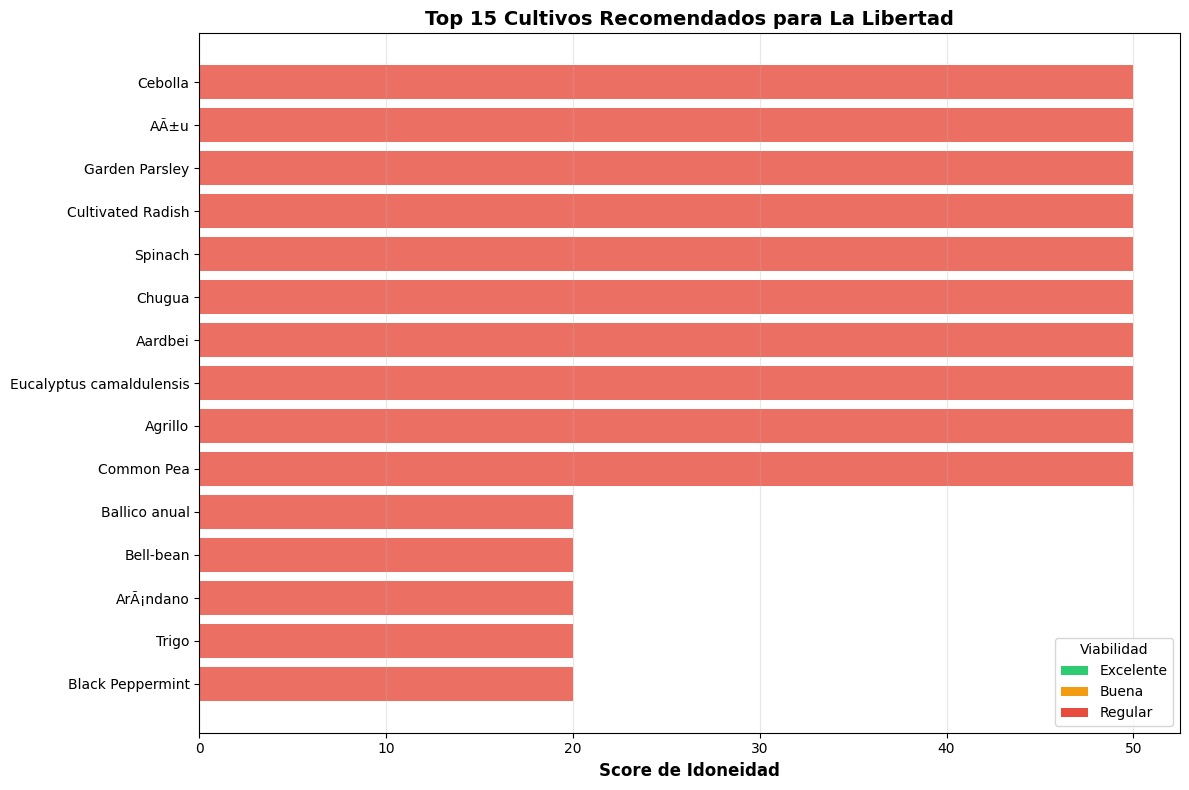

✓ Visualización de recomendaciones generada


In [0]:
# Visualizar top cultivos recomendados
top_n = min(15, len(df_recommendations))
top_crops = df_recommendations.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))

# Colores por viabilidad
color_map = {'Excelente': '#2ecc71', 'Buena': '#f39c12', 'Regular': '#e74c3c'}
colors = [color_map[v] for v in top_crops['Viabilidad']]

# Crear gráfico de barras horizontal
ax.barh(range(len(top_crops)), top_crops['Score'], color=colors, alpha=0.8)
ax.set_yticks(range(len(top_crops)))
ax.set_yticklabels(top_crops['Cultivo'])
ax.invert_yaxis()
ax.set_xlabel('Score de Idoneidad', fontsize=12, fontweight='bold')
zona_info = info_provincias.get(PROVINCIA_SELECCIONADA, {})
ax.set_title(f'Top {top_n} Cultivos Recomendados - {zona_info.get("nombre", f"Prov{PROVINCIA_SELECCIONADA}")} (Provincia {PROVINCIA_SELECCIONADA})', fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

# Añadir leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[k], label=k) for k in ['Excelente', 'Buena', 'Regular']]
ax.legend(handles=legend_elements, loc='lower right', title='Viabilidad')

plt.tight_layout()
plt.show()

print("✓ Visualización de recomendaciones generada")

In [0]:
# Preparar y guardar predicciones futuras
df_future_save = df_future.reset_index()
df_future_save.columns = ['Fecha', 'TemperaturaMax', 'TemperaturaMin', 'Precipitacion', 'Humedad']
df_future_save['FechaPrediccion'] = datetime.now()
df_future_save['ModeloVersion'] = f'LSTM_v1_Prov{PROVINCIA_SELECCIONADA}'
df_future_save['Provincia'] = PROVINCIA_SELECCIONADA
df_future_save['ZonaNombre'] = info_provincias.get(PROVINCIA_SELECCIONADA, {}).get('nombre', f'Prov{PROVINCIA_SELECCIONADA}')

# Eliminar tabla anterior si existe (para evitar conflictos de schema)
spark.sql("DROP TABLE IF EXISTS workspace.default.predicciones_climaticas")

# Convertir a Spark DataFrame y guardar
spark_predictions = spark.createDataFrame(df_future_save)
spark_predictions.write.mode('overwrite').saveAsTable('workspace.default.predicciones_climaticas')

print("✓ Predicciones guardadas en: workspace.default.predicciones_climaticas")

# Guardar recomendaciones
df_recommendations['FechaGeneracion'] = datetime.now()
df_recommendations['PeriodoPrediccion'] = f"{future_dates[0].strftime('%Y-%m-%d')} a {future_dates[-1].strftime('%Y-%m-%d')}"
df_recommendations['Region'] = 'La Libertad'
df_recommendations['Provincia'] = PROVINCIA_SELECCIONADA
df_recommendations['ZonaNombre'] = info_provincias.get(PROVINCIA_SELECCIONADA, {}).get('nombre', f'Prov{PROVINCIA_SELECCIONADA}')

# Eliminar tabla anterior si existe
spark.sql("DROP TABLE IF EXISTS workspace.default.recomendaciones_cultivos")

spark_recommendations = spark.createDataFrame(df_recommendations)
spark_recommendations.write.mode('overwrite').saveAsTable('workspace.default.recomendaciones_cultivos')

print("✓ Recomendaciones guardadas en: workspace.default.recomendaciones_cultivos")

print("\n" + "="*60)
print("PROCESO COMPLETADO EXITOSAMENTE")
print("="*60)
zona_info = info_provincias.get(PROVINCIA_SELECCIONADA, {})
print(f"\n🎯 Zona de predicción: {zona_info.get('nombre', f'Prov{PROVINCIA_SELECCIONADA}')} (Provincia {PROVINCIA_SELECCIONADA})")
print(f"\nTablas generadas:")
print(f"  1. workspace.default.predicciones_climaticas - {len(df_future_save)} registros")
print(f"  2. workspace.default.recomendaciones_cultivos - {len(df_recommendations)} cultivos recomendados")
print(f"\nModelo LSTM registrado en MLflow")
print(f"Experimento: /Users/lmauriccib1@upao.edu.pe/LSTM-Prediccion-Clima")
print(f"Run: LSTM_{zona_info.get('nombre', 'N/A').replace('/', '_')}_Prov{PROVINCIA_SELECCIONADA}")

✓ Predicciones guardadas en: workspace.default.predicciones_climaticas
✓ Recomendaciones guardadas en: workspace.default.recomendaciones_cultivos

PROCESO COMPLETADO EXITOSAMENTE

🎯 Zona de predicción: Trujillo (Provincia 4)

Tablas generadas:
  1. workspace.default.predicciones_climaticas - 30 registros
  2. workspace.default.recomendaciones_cultivos - 101 cultivos recomendados

Modelo LSTM registrado en MLflow
Experimento: /Users/lmauriccib1@upao.edu.pe/LSTM-Prediccion-Clima
Run: LSTM_Trujillo_Prov4


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# TensorFlow y Keras para LSTM
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Scikit-learn para preprocesamiento
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# MLflow para tracking
import mlflow
import mlflow.tensorflow

print("✓ Bibliotecas importadas correctamente")
print(f"TensorFlow version: {tf.__version__}")

✓ Bibliotecas importadas correctamente
TensorFlow version: 2.21.0


In [0]:
# ============================================================
# FUNCIÓN REUTILIZABLE: Predecir clima por provincia
# ============================================================

# Diccionario con información de provincias
PROVINCIAS_INFO = {
    1: {"nombre": "Callancas/Salpo/Usquil", "zona": "Sierra", "temp_historica": 13.9, "caracteristicas": "Sierra, temperaturas bajas"},
    3: {"nombre": "Cascas/Lucma/Marmot", "zona": "Intermedia", "temp_historica": 16.4, "caracteristicas": "Zona intermedia, clima templado"},
    4: {"nombre": "Trujillo", "zona": "Costa", "temp_historica": 23.4, "caracteristicas": "Costa, clima cálido y seco"},
    5: {"nombre": "Casagrande", "zona": "Valle", "temp_historica": 18.4, "caracteristicas": "Valle costero, clima templado"},
    10: {"nombre": "Talla/Guadalupe", "zona": "Costa Norte", "temp_historica": 28.0, "caracteristicas": "Costa norte, muy cálido"},
    12: {"nombre": "Huamachuco", "zona": "Sierra Baja", "temp_historica": 18.7, "caracteristicas": "Sierra baja, clima templado"},
    13: {"nombre": "Mollepata/Cachicadan/Quiruvilca", "zona": "Sierra Alta", "temp_historica": 8.9, "caracteristicas": "Sierra alta, muy frío"}
}

def predecir_clima_provincia(provincia_id, dias_prediccion=30):
    """
    Predice el clima para una provincia específica de La Libertad.
    
    Parámetros:
        provincia_id (int): ID de la provincia (1, 3, 4, 5, 10, 12, 13)
        dias_prediccion (int): Número de días a predecir (default: 30)
    
    Retorna:
        DataFrame con predicciones diarias de temperatura, precipitación y humedad
    """
    import time
    start_time = time.time()
    
    # Validar provincia
    if provincia_id not in PROVINCIAS_INFO:
        raise ValueError(f"Provincia {provincia_id} no válida. Usar: {list(PROVINCIAS_INFO.keys())}")
    
    info = PROVINCIAS_INFO[provincia_id]
    print("="*70)
    print(f"🌤️  PREDICCIÓN CLIMÁTICA - {info['nombre'].upper()}")
    print("="*70)
    print(f"Provincia ID: {provincia_id} | Zona: {info['zona']}")
    print(f"Temperatura histórica: {info['temp_historica']}°C")
    print(f"Características: {info['caracteristicas']}")
    print(f"Días a predecir: {dias_prediccion}")
    print("="*70)
    
    # 1. CARGAR Y FILTRAR DATOS
    print("\n[1/6] Cargando datos...")
    df_estaciones_temp = spark.table("workspace.default.estacion").toPandas()
    estaciones_prov = df_estaciones_temp[df_estaciones_temp['IdProvincia'] == provincia_id]['IdEstacion'].tolist()
    
    if not estaciones_prov:
        raise ValueError(f"No hay estaciones para provincia {provincia_id}")
    
    df_mediciones_temp = spark.table("workspace.default.medicion").toPandas()
    df_prov = df_mediciones_temp[df_mediciones_temp['IdEstacion'].isin(estaciones_prov)].copy()
    
    print(f"   ✓ {len(estaciones_prov)} estación(es), {len(df_prov):,} mediciones")
    
    # 2. PREPARAR DATOS
    print("\n[2/6] Preparando datos...")
    df_prov['Fecha'] = pd.to_datetime(df_prov['Fecha'])
    for col in ['TemperaturaMax', 'TemperaturaMin', 'Precipitacion', 'Humedad']:
        df_prov[col] = pd.to_numeric(df_prov[col], errors='coerce')
    
    # Agrupar por día
    df_daily_temp = df_prov.groupby('Fecha').agg({
        'TemperaturaMax': 'mean',
        'TemperaturaMin': 'mean',
        'Precipitacion': 'mean',
        'Humedad': 'mean'
    }).sort_values('Fecha')
    
    # Interpolar valores faltantes
    df_daily_temp = df_daily_temp.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
    
    # Normalizar
    scaler_temp = MinMaxScaler(feature_range=(0, 1))
    scaled_temp = scaler_temp.fit_transform(df_daily_temp)
    
    print(f"   ✓ Dataset: {len(df_daily_temp)} días, 4 variables")
    
    # 3. CREAR SECUENCIAS
    print("\n[3/6] Creando secuencias...")
    LOOKBACK_TEMP = 30
    FORECAST_TEMP = 7
    
    X_list, y_list = [], []
    for i in range(LOOKBACK_TEMP, len(scaled_temp) - FORECAST_TEMP + 1):
        X_list.append(scaled_temp[i-LOOKBACK_TEMP:i])
        y_list.append(scaled_temp[i:i+FORECAST_TEMP])
    
    X_temp = np.array(X_list)
    y_temp = np.array(y_list)
    
    # Split train/val (85/15)
    split_idx = int(len(X_temp) * 0.85)
    X_train_temp = X_temp[:split_idx]
    y_train_temp = y_temp[:split_idx]
    X_val_temp = X_temp[split_idx:]
    y_val_temp = y_temp[split_idx:]
    
    print(f"   ✓ {X_temp.shape[0]} secuencias | Train: {X_train_temp.shape[0]}, Val: {X_val_temp.shape[0]}")
    
    # 4. CONSTRUIR Y ENTRENAR MODELO
    print("\n[4/6] Entrenando modelo LSTM...")
    n_features_temp = X_train_temp.shape[2]
    
    model_temp = Sequential([
        LSTM(32, activation='relu', return_sequences=False, input_shape=(LOOKBACK_TEMP, n_features_temp)),
        Dropout(0.2),
        Dense(FORECAST_TEMP * n_features_temp),
        tf.keras.layers.Reshape((FORECAST_TEMP, n_features_temp))
    ])
    
    model_temp.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    
    history_temp = model_temp.fit(
        X_train_temp, y_train_temp,
        validation_data=(X_val_temp, y_val_temp),
        epochs=15,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    
    val_loss = history_temp.history['val_loss'][-1]
    print(f"   ✓ Entrenado en {len(history_temp.history['loss'])} épocas | Val Loss: {val_loss:.4f}")
    
    # 5. GENERAR PREDICCIONES FUTURAS
    print(f"\n[5/6] Generando predicciones para {dias_prediccion} días...")
    last_seq = scaled_temp[-LOOKBACK_TEMP:].copy()
    predictions_list = []
    
    for _ in range(dias_prediccion):
        pred = model_temp.predict(last_seq.reshape(1, LOOKBACK_TEMP, -1), verbose=0)
        next_day = pred[0, 0, :]
        predictions_list.append(next_day)
        last_seq = np.vstack([last_seq[1:], next_day])
    
    # Desnormalizar
    predictions_array = np.array(predictions_list)
    predictions_inv = scaler_temp.inverse_transform(predictions_array)
    
    # Crear DataFrame
    last_date_temp = df_daily_temp.index[-1]
    future_dates_temp = pd.date_range(start=last_date_temp + timedelta(days=1), periods=dias_prediccion, freq='D')
    
    df_result = pd.DataFrame(
        predictions_inv,
        index=future_dates_temp,
        columns=['TemperaturaMax', 'TemperaturaMin', 'Precipitacion', 'Humedad']
    )
    
    print(f"   ✓ Predicciones generadas")
    
    # 6. MOSTRAR RESULTADOS
    print("\n[6/6] Resultados:")
    print("="*70)
    print(f"📅 Período: {future_dates_temp[0].strftime('%Y-%m-%d')} al {future_dates_temp[-1].strftime('%Y-%m-%d')}")
    print(f"\n🌡️  Temperatura Máxima Promedio: {df_result['TemperaturaMax'].mean():.1f}°C")
    print(f"🌡️  Temperatura Mínima Promedio: {df_result['TemperaturaMin'].mean():.1f}°C")
    print(f"🌧️  Precipitación Acumulada: {df_result['Precipitacion'].sum():.1f} mm")
    print(f"💧 Humedad Promedio: {df_result['Humedad'].mean():.1f}%")
    print("="*70)
    
    elapsed = time.time() - start_time
    print(f"\n⏱️  Tiempo de ejecución: {elapsed:.1f} segundos")
    print("\n✅ Predicción completada exitosamente\n")
    
    return df_result

In [0]:
import shutil
import os

# Rutas
source_dir = "/Workspace/Users/lmauriccib1@upao.edu.pe/models"
dest_dir = "/Workspace/Users/lmauriccib1@upao.edu.pe/clima-api/models"

print("🚚 MOVIENDO MODELOS A CLIMA-API...")
print("="*70)

# Listar archivos
archivos = [f for f in os.listdir(source_dir) if f.endswith(('.h5', '.pkl'))]
print(f"\n📦 {len(archivos)} archivos a mover")

# Mover archivos
for archivo in archivos:
    src = os.path.join(source_dir, archivo)
    dst = os.path.join(dest_dir, archivo)
    shutil.move(src, dst)

print(f"✅ {len(archivos)} archivos movidos")

# Verificar
archivos_finales = os.listdir(dest_dir)
modelos = len([f for f in archivos_finales if f.endswith('.h5')])
scalers = len([f for f in archivos_finales if 'scaler' in f])
metadatas = len([f for f in archivos_finales if 'metadata' in f])

print(f"\n📁 Archivos en clima-api/models/:")
print(f"  🧠 Modelos: {modelos}")
print(f"  📊 Scalers: {scalers}")
print(f"  📝 Metadata: {metadatas}")
print(f"  📦 TOTAL: {len(archivos_finales)}")
print("\n✅ Listo para descargar y desplegar!")

🚚 MOVIENDO MODELOS A CLIMA-API...

📦 21 archivos a mover
✅ 21 archivos movidos

📁 Archivos en clima-api/models/:
  🧠 Modelos: 7
  📊 Scalers: 7
  📝 Metadata: 7
  📦 TOTAL: 21

✅ Listo para descargar y desplegar!


In [0]:
# ============================================================
# FUNCIÓN PARA ENTRENAR MODELOS POR ESTACIÓN
# ============================================================

import pickle
import os
from datetime import datetime
import time

def entrenar_modelo_estacion(estacion_id, estacion_nombre):
    """
    Entrena un modelo LSTM para una estación específica y guarda:
    - Modelo entrenado (.h5)
    - Scaler (.pkl)
    - Metadata (.pkl)
    
    Args:
        estacion_id (str): ID de la estación
        estacion_nombre (str): Nombre de la estación
    
    Returns:
        dict: Métricas del modelo entrenado
    """
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import MinMaxScaler
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dropout, Dense
    from tensorflow.keras.callbacks import EarlyStopping
    import tensorflow as tf
    
    start_time = time.time()
    
    print("\n" + "="*70)
    print(f"📡 ENTRENANDO MODELO - {estacion_nombre.upper()}")
    print("="*70)
    print(f"Estación: {estacion_id}")
    
    # ========================================
    # 1. CARGAR Y FILTRAR DATOS
    # ========================================
    print("\n[1/7] Cargando datos...")
    df_mediciones_temp = spark.table("workspace.default.medicion").toPandas()
    df_est = df_mediciones_temp[df_mediciones_temp['IdEstacion'] == estacion_id].copy()
    
    if len(df_est) == 0:
        raise ValueError(f"No hay mediciones para estación {estacion_id}")
    
    print(f"   ✓ {len(df_est):,} mediciones")
    
    # ========================================
    # 2. PREPARAR DATOS
    # ========================================
    print("\n[2/7] Preparando datos...")
    df_est['Fecha'] = pd.to_datetime(df_est['Fecha'])
    for col in ['TemperaturaMax', 'TemperaturaMin', 'Precipitacion', 'Humedad']:
        df_est[col] = pd.to_numeric(df_est[col], errors='coerce')
    
    # Agrupar por día
    df_daily_temp = df_est.groupby('Fecha').agg({
        'TemperaturaMax': 'mean',
        'TemperaturaMin': 'mean',
        'Precipitacion': 'mean',
        'Humedad': 'mean'
    }).sort_values('Fecha')
    
    # Interpolar valores faltantes
    df_daily_temp = df_daily_temp.set_index('Fecha') if 'Fecha' in df_daily_temp.columns else df_daily_temp
    df_daily_temp = df_daily_temp.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
    
    # Normalizar
    scaler_temp = MinMaxScaler(feature_range=(0, 1))
    scaled_temp = scaler_temp.fit_transform(df_daily_temp.values)
    
    print(f"   ✓ Dataset: {len(df_daily_temp)} días, 4 variables")
    
    # ========================================
    # 3. CREAR SECUENCIAS
    # ========================================
    print("\n[3/7] Creando secuencias...")
    LOOKBACK_TEMP = 30
    FORECAST_TEMP = 7
    
    X_list, y_list = [], []
    for i in range(LOOKBACK_TEMP, len(scaled_temp) - FORECAST_TEMP + 1):
        X_list.append(scaled_temp[i-LOOKBACK_TEMP:i])
        y_list.append(scaled_temp[i:i+FORECAST_TEMP])
    
    X_temp = np.array(X_list)
    y_temp = np.array(y_list)
    
    # Split train/val (85/15)
    split_idx = int(len(X_temp) * 0.85)
    X_train_temp = X_temp[:split_idx]
    y_train_temp = y_temp[:split_idx]
    X_val_temp = X_temp[split_idx:]
    y_val_temp = y_temp[split_idx:]
    
    print(f"   ✓ {X_temp.shape[0]} secuencias | Train: {X_train_temp.shape[0]}, Val: {X_val_temp.shape[0]}")
    
    # ========================================
    # 4. CONSTRUIR MODELO
    # ========================================
    print("\n[4/7] Construyendo modelo LSTM...")
    n_features_temp = X_train_temp.shape[2]
    
    model_temp = Sequential([
        LSTM(32, activation='relu', return_sequences=False, input_shape=(LOOKBACK_TEMP, n_features_temp)),
        Dropout(0.2),
        Dense(FORECAST_TEMP * n_features_temp),
        tf.keras.layers.Reshape((FORECAST_TEMP, n_features_temp))
    ])
    
    model_temp.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    print(f"   ✓ Arquitectura: LSTM(32) -> Dropout(0.2) -> Dense({FORECAST_TEMP * n_features_temp})")
    
    # ========================================
    # 5. ENTRENAR MODELO
    # ========================================
    print("\n[5/7] Entrenando modelo...")
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    
    history_temp = model_temp.fit(
        X_train_temp, y_train_temp,
        validation_data=(X_val_temp, y_val_temp),
        epochs=15,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    
    val_loss = history_temp.history['val_loss'][-1]
    val_mae = history_temp.history['val_mae'][-1]
    epochs_run = len(history_temp.history['loss'])
    
    print(f"   ✓ Épocas: {epochs_run} | Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f}")
    
    # ========================================
    # 6. GUARDAR ARCHIVOS
    # ========================================
    print("\n[6/7] Guardando archivos...")
    
    # Crear directorio
    models_dir = "/Workspace/Users/lmauriccib1@upao.edu.pe/clima-api/models"
    os.makedirs(models_dir, exist_ok=True)
    
    # Nombre seguro para archivos (reemplazar caracteres especiales)
    nombre_archivo = estacion_nombre.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    
    # Rutas de archivos
    model_path = f"{models_dir}/modelo_{nombre_archivo}.h5"
    scaler_path = f"{models_dir}/scaler_{nombre_archivo}.pkl"
    metadata_path = f"{models_dir}/metadata_{nombre_archivo}.pkl"
    
    # Guardar modelo
    model_temp.save(model_path)
    print(f"   ✓ Modelo: .../{nombre_archivo}.h5")
    
    # Guardar scaler
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler_temp, f)
    print(f"   ✓ Scaler: .../{nombre_archivo}.pkl")
    
    # Guardar metadata
    metadata = {
        'estacion_id': estacion_id,
        'estacion_nombre': estacion_nombre,
        'last_date': df_daily_temp.index[-1],
        'num_registros': len(df_daily_temp),
        'lookback': LOOKBACK_TEMP,
        'forecast_horizon': FORECAST_TEMP,
        'val_loss': float(val_loss),
        'val_mae': float(val_mae),
        'epochs_run': epochs_run,
        'trained_at': datetime.now(),
        'feature_names': ['TemperaturaMax', 'TemperaturaMin', 'Precipitacion', 'Humedad']
    }
    
    with open(metadata_path, 'wb') as f:
        pickle.dump(metadata, f)
    print(f"   ✓ Metadata: .../{nombre_archivo}.pkl")
    
    # ========================================
    # 7. RESUMEN
    # ========================================
    elapsed = time.time() - start_time
    print(f"\n[7/7] ✅ Completado en {elapsed:.1f} seg")
    
    return {
        'estacion_id': estacion_id,
        'estacion_nombre': estacion_nombre,
        'val_loss': float(val_loss),
        'val_mae': float(val_mae),
        'epochs': epochs_run,
        'tiempo_seg': elapsed
    }

print("✅ Función 'entrenar_modelo_estacion' creada")
print("\n💡 Uso: entrenar_modelo_estacion('108068', 'TRUJILLO')")

✅ Función 'entrenar_modelo_estacion' creada

💡 Uso: entrenar_modelo_estacion('108068', 'TRUJILLO')


In [0]:
import time
import os

print("\n🌍 ESTACIONES A ENTRENAR:", len(estaciones_para_entrenar))
for est_id in estaciones_para_entrenar:
    nombre = estaciones_activas[estaciones_activas['IdEstacion']==est_id]['Nombre'].values[0]
    print(f"  {est_id} - {nombre}")

print("\n🚀 Iniciando...\n")

start_total = time.time()
resultados = []

for i, est_id in enumerate(estaciones_para_entrenar, 1):
    print(f"\n[{i}/{len(estaciones_para_entrenar)}] =====================")
    nombre = estaciones_activas[estaciones_activas['IdEstacion']==est_id]['Nombre'].values[0]
    
    try:
        resultado = entrenar_modelo_estacion(est_id, nombre)
        resultados.append(resultado)
        print(f"✅ {nombre}: Loss={resultado['val_loss']:.4f}")
    except Exception as e:
        print(f"❌ Error: {e}")
        resultados.append({'estacion_id': est_id, 'error': str(e)})

print(f"\n\n✅ Completado en {(time.time()-start_total)/60:.1f} min")
print(f"Modelos: {len([r for r in resultados if 'error' not in r])}/{len(estaciones_para_entrenar)}")

# Listar archivos
models_dir = "/Workspace/Users/lmauriccib1@upao.edu.pe/clima-api/models"
archivos = os.listdir(models_dir)
print(f"\n📁 {len(archivos)} archivos en models/")
print(f"  Modelos: {len([f for f in archivos if f.endswith('.h5')])}")
print(f"  Scalers: {len([f for f in archivos if 'scaler' in f])}")
print(f"  Metadata: {len([f for f in archivos if 'metadata' in f])}")


🌍 ESTACIONES A ENTRENAR: 16
  472C2CB6 - MARMOT
  107054 - CALLANCAS
  472D60B4 - USQUIL
  472EB1D2 - CAPACHIQUE
  107131 - LA FORTUNA
  4727319A - QUIRUVILCA
  472D552E - LUCMA
  472EA2A4 - CASCAS
  108045 - CACHICADAN
  107009 - HUAMACHUCO
  108068 - TRUJILLO
  108001 - SALPO
  472D30C8 - CASAGRANDE
  100136 - TALLA (GUADALUPE)
  108046 - MOLLEPATA
  108048 - Huacamarcanga

🚀 Iniciando...


[1/16] =====================

📡 ENTRENANDO MODELO - MARMOT
Estación: 472C2CB6

[1/7] Cargando datos...
   ✓ 43,677 mediciones

[2/7] Preparando datos...


/home/spark-f5189a19-8a27-43b3-b346-86/.ipykernel/308/command-5670059189671972-3250668849:69: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily_temp = df_daily_temp.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
/databricks/python/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/databricks/python/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/local_disk0/.ephemeral_nfs/envs/pythonEnv-f5189a19-8a27-43b3-b346-863005c412a3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model inst

   ✓ Dataset: 1823 días, 4 variables

[3/7] Creando secuencias...
   ✓ 1787 secuencias | Train: 1518, Val: 269

[4/7] Construyendo modelo LSTM...
   ✓ Arquitectura: LSTM(32) -> Dropout(0.2) -> Dense(28)

[5/7] Entrenando modelo...


   ✓ Épocas: 6 | Val Loss: nan | Val MAE: nan

[6/7] Guardando archivos...
   ✓ Modelo: .../MARMOT.h5
   ✓ Scaler: .../MARMOT.pkl
   ✓ Metadata: .../MARMOT.pkl

[7/7] ✅ Completado en 7.3 seg
✅ MARMOT: Loss=nan

[2/16] =====================

📡 ENTRENANDO MODELO - CALLANCAS
Estación: 107054

[1/7] Cargando datos...
   ✓ 43,504 mediciones

[2/7] Preparando datos...


/home/spark-f5189a19-8a27-43b3-b346-86/.ipykernel/308/command-5670059189671972-3250668849:69: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily_temp = df_daily_temp.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
/local_disk0/.ephemeral_nfs/envs/pythonEnv-f5189a19-8a27-43b3-b346-863005c412a3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

   ✓ Épocas: 12 | Val Loss: 0.0047 | Val MAE: 0.0472

[6/7] Guardando archivos...
   ✓ Modelo: .../TALLA_GUADALUPE.h5
   ✓ Scaler: .../TALLA_GUADALUPE.pkl
   ✓ Metadata: .../TALLA_GUADALUPE.pkl

[7/7] ✅ Completado en 10.6 seg
✅ TALLA (GUADALUPE): Loss=0.0047

[15/16] =====================

📡 ENTRENANDO MODELO - MOLLEPATA
Estación: 108046

[1/7] Cargando datos...
   ✓ 1,826 mediciones

[2/7] Preparando datos...
   ✓ Dataset: 1826 días, 4 variables

[3/7] Creando secuencias...
   ✓ 1790 secuencias | Train: 1521, Val: 269

[4/7] Construyendo modelo LSTM...
   ✓ Arquitectura: LSTM(32) -> Dropout(0.2) -> Dense(28)

[5/7] Entrenando modelo...


/home/spark-f5189a19-8a27-43b3-b346-86/.ipykernel/308/command-5670059189671972-3250668849:69: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily_temp = df_daily_temp.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
/local_disk0/.ephemeral_nfs/envs/pythonEnv-f5189a19-8a27-43b3-b346-863005c412a3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   ✓ Épocas: 15 | Val Loss: 0.0132 | Val MAE: 0.0749

[6/7] Guardando archivos...
   ✓ Modelo: .../MOLLEPATA.h5
   ✓ Scaler: .../MOLLEPATA.pkl
   ✓ Metadata: .../MOLLEPATA.pkl

[7/7] ✅ Completado en 12.0 seg
✅ MOLLEPATA: Loss=0.0132

[16/16] =====================

📡 ENTRENANDO MODELO - HUACAMARCANGA
Estación: 108048

[1/7] Cargando datos...
   ✓ 1,826 mediciones

[2/7] Preparando datos...
   ✓ Dataset: 1826 días, 4 variables

[3/7] Creando secuencias...
   ✓ 1790 secuencias | Train: 1521, Val: 269

[4/7] Construyendo modelo LSTM...
   ✓ Arquitectura: LSTM(32) -> Dropout(0.2) -> Dense(28)

[5/7] Entrenando modelo...


/home/spark-f5189a19-8a27-43b3-b346-86/.ipykernel/308/command-5670059189671972-3250668849:69: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily_temp = df_daily_temp.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
/local_disk0/.ephemeral_nfs/envs/pythonEnv-f5189a19-8a27-43b3-b346-863005c412a3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   ✓ Épocas: 8 | Val Loss: 0.0550 | Val MAE: 0.1435

[6/7] Guardando archivos...
   ✓ Modelo: .../Huacamarcanga.h5
   ✓ Scaler: .../Huacamarcanga.pkl
   ✓ Metadata: .../Huacamarcanga.pkl

[7/7] ✅ Completado en 8.1 seg
✅ Huacamarcanga: Loss=0.0550


✅ Completado en 3.4 min
Modelos: 16/16

📁 48 archivos en models/
  Modelos: 16
  Scalers: 16
  Metadata: 16


In [0]:
# ============================================================
# PRUEBA: ENTRENAR UNA ESTACIÓN (TRUJILLO)
# ============================================================

import time
import os

print("\n" + "="*70)
print("🧪 PRUEBA DE ENTRENAMIENTO - UNA ESTACIÓN")
print("="*70)

# Entrenar solo TRUJILLO como prueba
estacion_prueba = '108068'
nombre_prueba = 'TRUJILLO'

print(f"\nEstación de prueba: {estacion_prueba} - {nombre_prueba}")
print(f"Registros: 3,164 (rápido)")
print(f"Tiempo estimado: 2-3 minutos\n")

start_time = time.time()

try:
    resultado = entrenar_modelo_estacion(estacion_prueba, nombre_prueba)
    
    print("\n" + "="*70)
    print("✅ PRUEBA EXITOSA")
    print("="*70)
    print(f"\n📊 Resultados:")
    print(f"  Estación: {resultado['estacion_nombre']}")
    print(f"  Val Loss: {resultado['val_loss']:.4f}")
    print(f"  Val MAE: {resultado['val_mae']:.4f}")
    print(f"  Épocas: {resultado['epochs']}")
    print(f"  Tiempo: {resultado['tiempo_seg']:.1f} segundos")
    
    # Verificar archivos generados
    models_dir = "/Workspace/Users/lmauriccib1@upao.edu.pe/clima-api/models"
    archivos = os.listdir(models_dir)
    modelos = [f for f in archivos if f.endswith('.h5')]
    scalers = [f for f in archivos if 'scaler' in f]
    metadatas = [f for f in archivos if 'metadata' in f]
    
    print(f"\n📁 Archivos generados:")
    print(f"  ✅ Modelo: {len(modelos)} archivo(s)")
    print(f"  ✅ Scaler: {len(scalers)} archivo(s)")
    print(f"  ✅ Metadata: {len(metadatas)} archivo(s)")
    print(f"  📦 Total: {len(archivos)} archivos")
    
    print(f"\n⏱️  Tiempo total: {(time.time()-start_time)/60:.2f} minutos")
    
    print("\n" + "="*70)
    print("🎯 LISTO PARA ENTRENAR LAS 16 ESTACIONES")
    print("="*70)
    print(f"\nSi todo se ve bien, ejecuta la celda anterior para entrenar")
    print(f"todas las estaciones (tiempo estimado: 30-45 minutos)")
    
except Exception as e:
    print("\n" + "="*70)
    print("❌ ERROR EN PRUEBA")
    print("="*70)
    print(f"\nError: {str(e)}")
    print(f"\nDebug: Verifica que las librerías estén importadas correctamente")


🧪 PRUEBA DE ENTRENAMIENTO - UNA ESTACIÓN

Estación de prueba: 108068 - TRUJILLO
Registros: 3,164 (rápido)
Tiempo estimado: 2-3 minutos


📡 ENTRENANDO MODELO - TRUJILLO
Estación: 108068

[1/7] Cargando datos...
   ✓ 3,164 mediciones

[2/7] Preparando datos...
   ✓ Dataset: 3160 días, 4 variables

[3/7] Creando secuencias...
   ✓ 3124 secuencias | Train: 2655, Val: 469

[4/7] Construyendo modelo LSTM...
   ✓ Arquitectura: LSTM(32) -> Dropout(0.2) -> Dense(28)

[5/7] Entrenando modelo...


/home/spark-f5189a19-8a27-43b3-b346-86/.ipykernel/308/command-5670059189671972-3250668849:69: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily_temp = df_daily_temp.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
/local_disk0/.ephemeral_nfs/envs/pythonEnv-f5189a19-8a27-43b3-b346-863005c412a3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   ✓ Épocas: 15 | Val Loss: 0.0019 | Val MAE: 0.0331

[6/7] Guardando archivos...
   ✓ Modelo: .../TRUJILLO.h5
   ✓ Scaler: .../TRUJILLO.pkl
   ✓ Metadata: .../TRUJILLO.pkl

[7/7] ✅ Completado en 69.1 seg

✅ PRUEBA EXITOSA

📊 Resultados:
  Estación: TRUJILLO
  Val Loss: 0.0019
  Val MAE: 0.0331
  Épocas: 15
  Tiempo: 69.1 segundos

📁 Archivos generados:
  ✅ Modelo: 1 archivo(s)
  ✅ Scaler: 1 archivo(s)
  ✅ Metadata: 1 archivo(s)
  📦 Total: 3 archivos

⏱️  Tiempo total: 1.23 minutos

🎯 LISTO PARA ENTRENAR LAS 16 ESTACIONES

Si todo se ve bien, ejecuta la celda anterior para entrenar
todas las estaciones (tiempo estimado: 30-45 minutos)
